# Common Libraries

In [15]:
import os, shutil
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt

if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Params

In [8]:
model_path = "/home/seojin/biomechanics_tools/myo_sim/arm/myoarm.xml"

# Initialize model

In [20]:
model = mujoco.MjModel.from_xml_path(model_path)
mj_data = mujoco.MjData(model)
mujoco.mj_forward(model, mj_data)

joint_names = [mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_JOINT, idx) for idx in range(model.njnt)]

# Plot

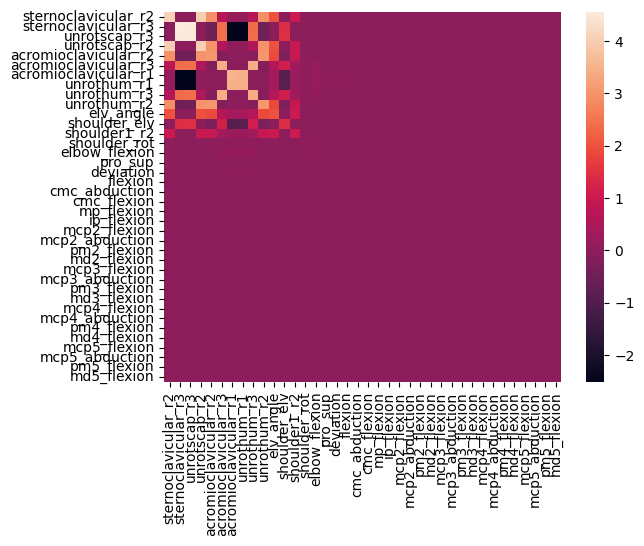

In [21]:
M_matrix = np.zeros((model.nv, model.nv))
mujoco.mj_fullM(model, M_matrix, mj_data.qM)
sns.heatmap(M_matrix)
plt.xticks(np.arange(len(joint_names)) + 0.5, joint_names, rotation = 90)
plt.yticks(np.arange(len(joint_names)) + 0.5, joint_names, rotation = 0)

None